In [1]:
import os
import numpy as np
import pandas as pd
from methyldl.deconvolution.uxm import load_atlas
import pickle

In [2]:
assembly = "hg38"

#### Analyze top-25 regions

In [3]:
import sys
atlas_location = f"../../UXM_deconv/supplemental/Atlas.U25.l4.{assembly}.full.tsv"
atlas, ref_cells = load_atlas(atlas_location)
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import entropy


def score_methylation_regions(df):
    # Separate metadata columns from cell-type data columns
    metadata_cols = [
        "chr",
        "start",
        "end",
        "startCpG",
        "endCpG",
        "target",
        "name",
        "direction",
    ]
    cell_type_cols = [c for c in df.columns if c not in metadata_cols]

    results = []

    for idx, row in df.iterrows():
        target_cell = row["target"]

        # Extract target value and background values
        target_val = row[target_cell]
        obs_vals = row[cell_type_cols].astype(float).values
        bg_vals = [row[c] for c in cell_type_cols if c != target_cell]

        # 1. Basic Entropy
        # Normalize observed values to create a valid probability distribution
        obs_sum = np.sum(obs_vals)
        if obs_sum > 0:
            q_dist = obs_vals / obs_sum
        else:
            q_dist = np.ones_like(obs_vals) / len(
                obs_vals
            )  # uniform fallback if all are zero

        ent = entropy(q_dist, base=2)

        # 2. KL-Divergence
        # P is the ideal distribution (1 for target cell, 0 elsewhere)
        p_dist = np.zeros_like(obs_vals)
        target_idx = cell_type_cols.index(target_cell)
        p_dist[target_idx] = 1.0

        kl_div = entropy(p_dist, q_dist, base=2)

        # 3. Proxy GSC (Target - Max Background)
        max_bg = np.max(bg_vals)
        gsc = target_val - max_bg

        # 4. Delta from Average Background (Target - Mean Background)
        mean_bg = np.mean(bg_vals)
        delta_avg = target_val - mean_bg

        results.append(
            {
                "name": row["name"],
                "entropy": ent,
                "kl_divergence": kl_div,
                "proxy_GSC": gsc,
                "delta_avg_bg": delta_avg,
            }
        )

    # Convert results to DataFrame and merge with original
    res_df = pd.DataFrame(results)
    final_df = pd.merge(df, res_df, on="name")

    return final_df



In [5]:
scored_df = score_methylation_regions(atlas)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


def plot_methylation_metric(
    scored_df,
    metric,
    is_ascending,
    title,
    bw=False,
    output_path=None,
    palette=None,
    show_xlabel=True,
    show_ylabel=True,
    figsize=(7, 6),
):
    """
    Plot a single methylation metric as a boxplot ranked by median.

    Parameters
    ----------
    scored_df : pd.DataFrame
        DataFrame with methylation metrics and a 'target' column.
    metric : str
        Column name of the metric to plot.
    is_ascending : bool
        True if lower values are better (rank 1 = lowest median).
    title : str
        Plot title.
    bw : bool, optional
        If True, save an additional grayscale version.
    output_path : str or None, optional
        Path to save the figure. Defaults to '{metric}_boxplot.png'.
    palette : dict or None, optional
        Mapping of target cell type -> color. Auto-generated if None.
    show_xlabel : bool, optional
        Whether to show x-axis label and tick labels.
    show_ylabel : bool, optional
        Whether to show y-axis label and tick labels.
    figsize : tuple, optional
        Figure size in inches.
    """
    plot_df = scored_df.copy()
    targets = plot_df["target"].unique()

    if palette is None:
        colors = sns.color_palette("tab10", n_colors=len(targets))
        palette = dict(zip(sorted(targets), colors))

    if output_path is None:
        output_path = f"{metric}_boxplot.png"

    medians = plot_df.groupby("target")[metric].median()
    sorted_targets = medians.sort_values(ascending=is_ascending).index.tolist()
    ranked_labels = {t: f"{rank+1}. {t}" for rank, t in enumerate(sorted_targets)}

    rank_col_name = f"ranked_{metric}"
    plot_df[rank_col_name] = plot_df["target"].map(ranked_labels)
    order = [ranked_labels[t] for t in sorted_targets]
    ranked_palette = {ranked_labels[t]: palette[t] for t in sorted_targets}

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x=rank_col_name,
        y=metric,
        order=order,
        ax=ax,
        palette=ranked_palette,
    )

    metrics_dict = {
        "kl_divergence": "KL-Divergence (Lower is better)",
        "proxy_GCS": "Proxy GSC (Higher is better)",
    }

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('' if show_xlabel else '', fontsize=12)
    ax.set_ylabel(metrics_dict[metric] if show_ylabel else '', fontsize=12)
    if not show_xlabel:
        ax.set_xticklabels([])
    if not show_ylabel:
        ax.set_yticklabels([])
    ax.tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()

    if bw:
        bw_path = output_path.rsplit(".", 1)
        bw_path = (
            f"{bw_path[0]}_bw.{bw_path[1]}"
            if len(bw_path) == 2
            else f"{output_path}_bw"
        )
        img = Image.open(output_path).convert("L")
        img.save(bw_path, dpi=(300, 300))
        print(f"Black-and-white version saved to: {bw_path}")

In [5]:
with open("per_region_mccs_test.pkl", "rb") as f:
    per_region_mccs = pickle.load(f)

In [6]:
scored_df_mcc = pd.merge(scored_df, per_region_mccs, on="name")

In [7]:
scored_df_mcc.dropna(inplace=True)
scored_df_mcc["kl_divergence"][scored_df_mcc["kl_divergence"] > 10] = sorted(
    scored_df_mcc["kl_divergence"]
)[-2]

/tmp/ipykernel_17806/4061365006.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  scored_df_mcc["kl_divergence"][scored_df_mcc["kl_divergence"]>10]=sorted(scored_df_mcc["kl_divergence"])[-2]
/tmp/ipykernel_17806/4061365006.py:2: SettingWit

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def plot_regression(x, y, x_label="X-axis", y_label="Y-axis"):
    """
    Plots a scatter plot of x and y, fits a linear regression line,
    and displays the R-squared value and regression equation.
    """
    # 1. Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # 2. Calculate R-squared
    r_squared = r_value**2

    # 3. Create the fitted line data
    # Equation: y = mx + b
    line = slope * np.array(x) + intercept

    # 4. Visualization
    plt.figure(figsize=(10, 6))

    # Scatter plot of raw data
    plt.scatter(x, y, alpha=0.6, edgecolors="w", label="Data Points")

    # Regression line
    plt.plot(
        x,
        line,
        color="red",
        linewidth=2,
        label=f"Fitted Line: y={slope:.2f}x + {intercept:.2f}",
    )

    # 5. Add R2 Annotation
    # We place the text in the "upper left" of the plot area
    plt.text(
        0.05,
        0.95,
        f"$R^2 = {r_squared:.3f}$",
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
    )

    # Aesthetics
    plt.title(f"Linear Regression: {y_label} vs {x_label}", fontsize=16)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.7)

    plt.show()

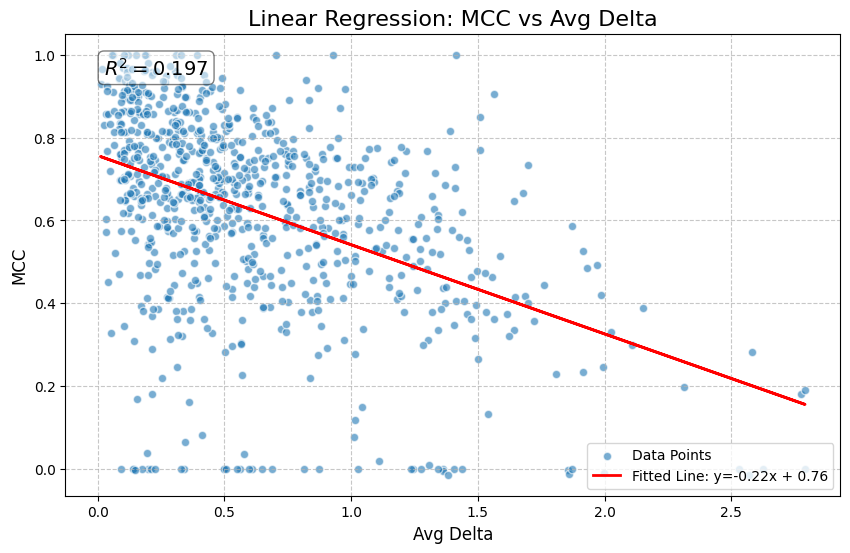

In [9]:
plot_regression(
    scored_df_mcc["kl_divergence"],
    scored_df_mcc["mcc"],
    x_label="Avg Delta",
    y_label="MCC",
)

In [13]:
LOYFER_COLORS = {
    "Blood-T": "#4e79a7",
    "Blood-B": "#59a14f",
    "Blood-Granul": "#e15759",
    "Blood-Mono+Macro": "#f28e2b",
    "Blood-NK": "#76b7b2",
    "Eryth-prog": "#b07aa1",
    "Endothelium": "#ff9da7",
    "Liver-Hep": "#9c755f",
    "Heart-Cardio": "#bab0ac",
    "Heart-Fibro": "#d4a373",
    "Kidney-Ep": "#edc948",
    "Lung-Ep-Alveo": "#aec7e8",
    "Lung-Ep-Bron": "#98d8c8",
    "Pancreas-Acinar": "#c7b198",
    "Pancreas-Duct": "#d4c5a9",
    "Pancreas-Alpha": "#e8d5b7",
    "Pancreas-Beta": "#c9ada7",
    "Pancreas-Delta": "#a8a39d",
    "Bladder-Ep": "#b5c99a",
    "Prostate-Ep": "#87bba2",
    "Small-Int-Ep": "#c49792",
    "Colon-Ep": "#a7c4bc",
    "Colon-Fibro": "#8fbc8f",
    "Dermal-Fibro": "#dda0dd",
    "Epid-Kerat": "#f0c987",
    "Breast-Basal-Ep": "#e6b0aa",
    "Breast-Luminal-Ep": "#d5a6bd",
    "Adipocytes": "#ffe0b2",
    "Head-Neck-Ep": "#bcaaa4",
    "Ovary+Endom-Ep": "#ce93d8",
    "Smooth-Musc": "#a1887f",
    "Skeletal-Musc": "#90a4ae",
    "Thyroid-Ep": "#80cbc4",
    "Neuron": "#fff59d",
    "Oligodend": "#c5e1a5",
    "Ovary-Ep": "#ce93d8",
    "unmapped": "#3a3a3a",
    "Bone-Osteob": "#d349d3",
    "Endothel": "#ff9da7",
    "Fallopian-Ep": "#d893c7",
    "Gallbladder": "#b5c99a",
    "Gastric-Ep": "#88e60f",
    "Megakaryocytes": "#ff0909"
}

/tmp/ipykernel_23919/2022584818.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


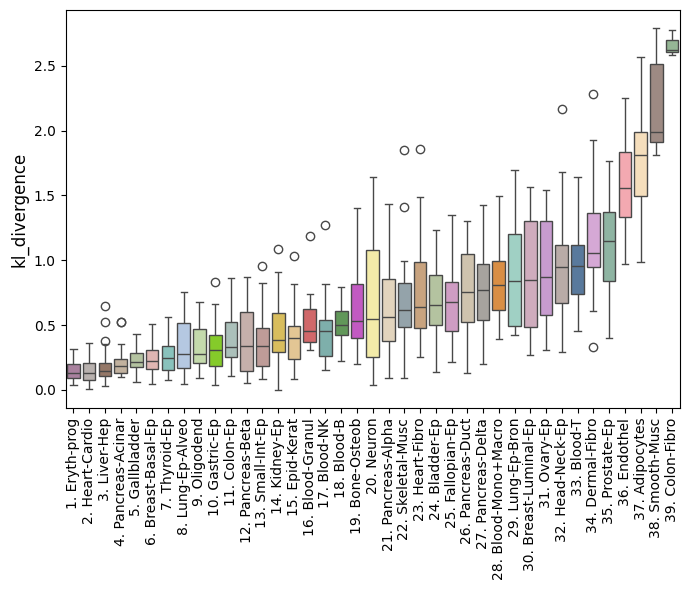

/tmp/ipykernel_23919/2022584818.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


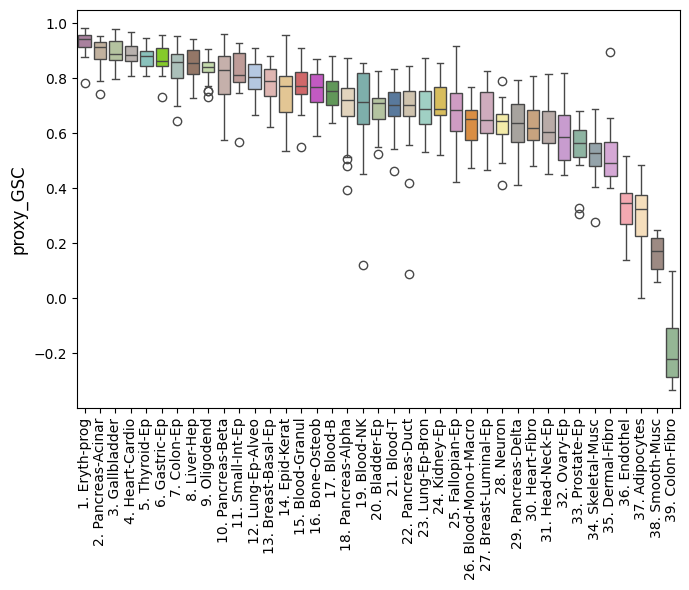

In [18]:
targets = scored_df['target'].unique()
# palette = dict(zip(sorted(targets), sns.color_palette('tab10', n_colors=len(targets))))
palette = LOYFER_COLORS

plot_methylation_metric(
    scored_df[scored_df["target"] != "Megakaryocytes"].dropna(),
    "kl_divergence",
    True,
    "",
    palette=palette,
    show_xlabel=True,
    show_ylabel=True,
)

plot_methylation_metric(
    scored_df[scored_df["target"] != "Megakaryocytes"].dropna(),
    "proxy_GSC",
    False,
    "",
    palette=palette,
    show_xlabel=True,
    show_ylabel=True,
)

/tmp/ipykernel_17806/2327000533.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_17806/2327000533.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


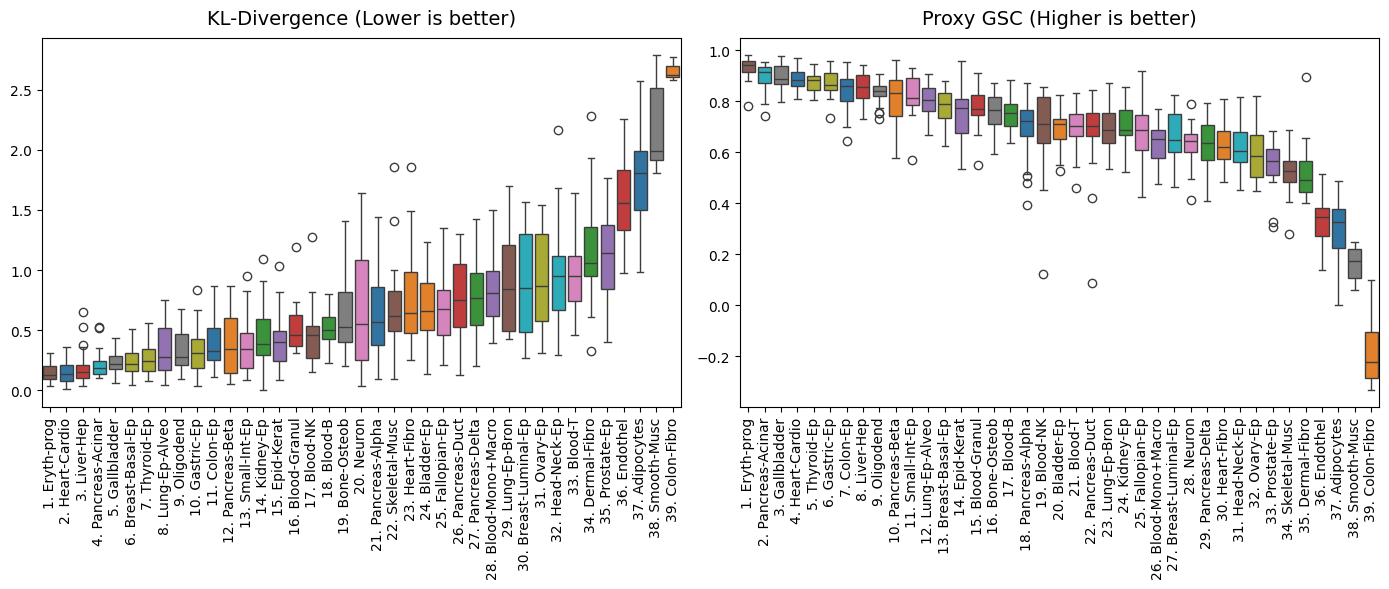

Black-and-white version saved to: ranked_metrics_boxplots_bw.png


In [31]:
plot_methylation_metrics(
    scored_df[scored_df["target"] != "Megakaryocytes"].dropna(), bw=True
)

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_target_regions_boxplot(df, selected_target):
    """
    Plots a boxplot of unmethylated reads percentage across all cell types
    for regions belonging to a single selected target cell type.
    """
    # Filter the dataframe for the selected target cell type
    target_df = df[df["target"] == selected_target]

    # Identify metadata vs cell type columns
    metadata_cols = [
        "chr",
        "start",
        "end",
        "startCpG",
        "endCpG",
        "target",
        "name",
        "direction",
    ]
    cell_type_cols = [c for c in df.columns if c not in metadata_cols]

    # Reshape data to long format so seaborn can easily plot it
    melted_df = target_df.melt(
        id_vars=["name"],
        value_vars=cell_type_cols,
        var_name="Cell_Type",
        value_name="Unmethylated_Reads_Percentage",
    )

    # Calculate medians to sort the x-axis from highest to lowest
    medians = (
        melted_df.groupby("Cell_Type")["Unmethylated_Reads_Percentage"]
        .median()
        .sort_values(ascending=False)
    )

    # Make a color palette: Red for the target cell type, light blue for background types
    palette = ["red" if ct == selected_target else "skyblue" for ct in medians.index]

    # Create the plot
    plt.figure(figsize=(18, 8))
    sns.boxplot(
        data=melted_df,
        x="Cell_Type",
        y="Unmethylated_Reads_Percentage",
        order=medians.index,
        palette=palette,
    )

    # Formatting the aesthetics
    plt.title(
        f"Percentage of Unmethylated Reads across Cell Types\n(Showing Regions Targeting: {selected_target})",
        fontsize=16,
    )
    plt.xlabel("Cell Type", fontsize=12)
    plt.ylabel("Unmethylated Reads (%)", fontsize=12)
    plt.xticks(rotation=90, ha="center", fontsize=10)  # Rotated for readability
    plt.tight_layout()

    # Save or Show
    plt.savefig(f"{selected_target}_boxplot.png")
    plt.show()


# Run the function on your full DataFrame:
# plot_target_regions_boxplot(df, 'Eryth-prog')

/tmp/ipykernel_329002/3473393595.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


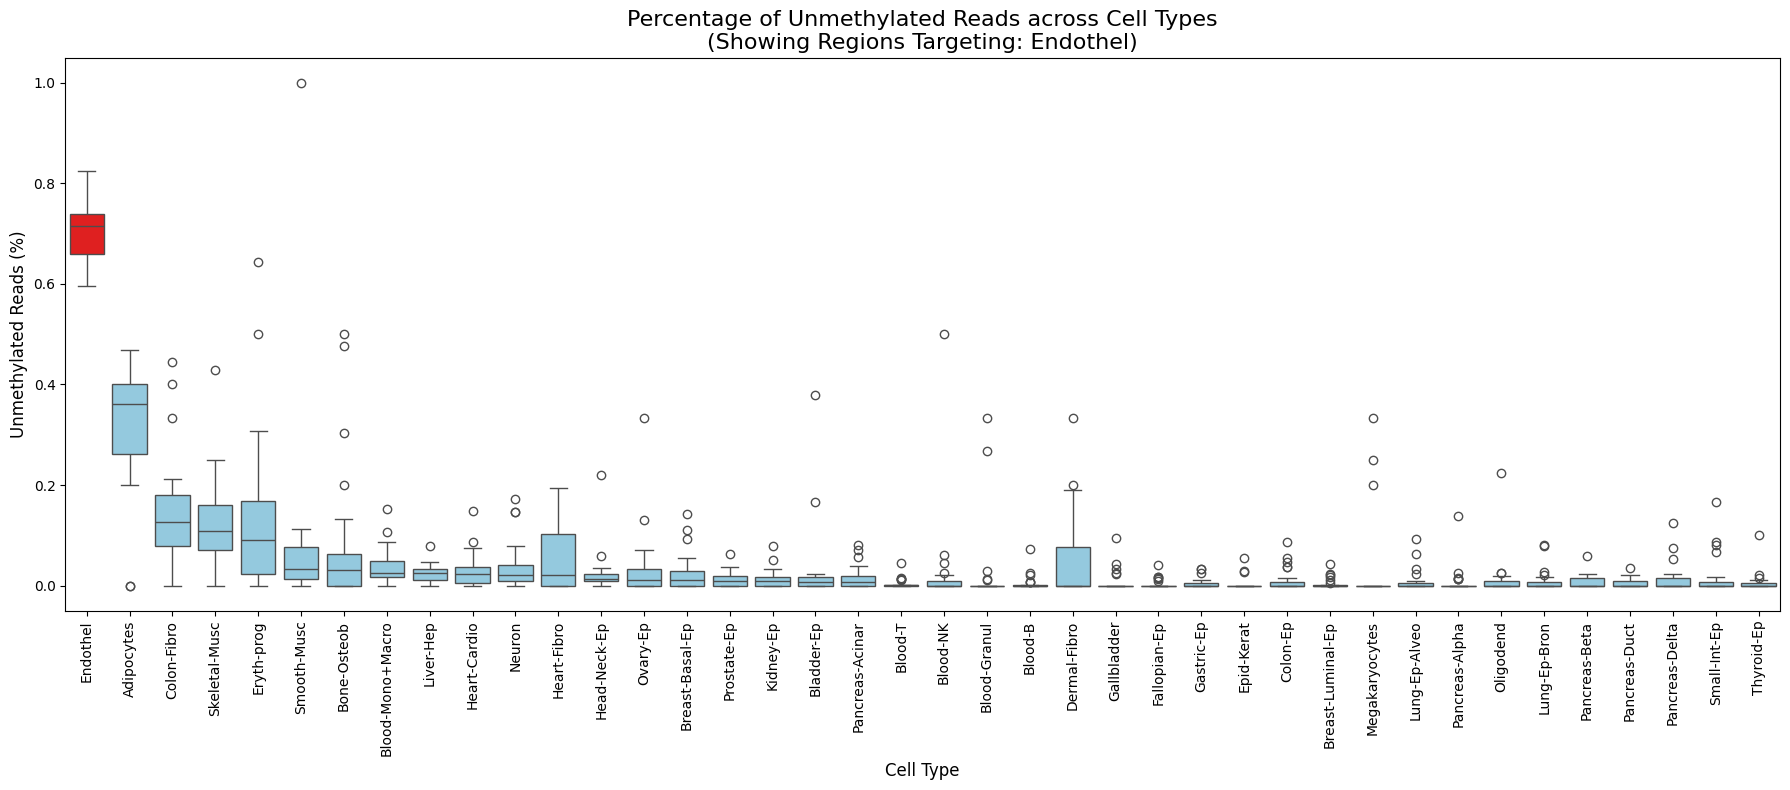

In [68]:
plot_target_regions_boxplot(atlas, selected_target="Endothel")

#### Analyze, if better regions can be selected from top-250

In [6]:
atlas_location = f"../../UXM_deconv/supplemental/Atlas.U250.l4.{assembly}.full.tsv"
atlas250, ref_cells = load_atlas(atlas_location)
atlas250 = atlas250.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

In [7]:
scored_df250 = score_methylation_regions(atlas250)

In [8]:
targets = set(scored_df250["target"])

In [9]:
scored_df250_sorted = scored_df250.dropna().sort_values("proxy_GSC", ascending=False)

In [10]:
subset = []
for target in targets:
    subset.append(scored_df250_sorted[scored_df250_sorted["target"] == target].head(25))

In [11]:
subset = pd.concat(subset)

In [19]:
subset["chr_int"] = subset["chr"].apply(lambda x: int(x.replace("chr", "")) if "X" not in x and "Y" not in x else x.replace("chr", ""))

In [26]:
subset.sort_values(["chr_int", "start"])[atlas250.columns].to_csv(f"Atlas.U25gscSorted.l4.{assembly}.full.tsv",index=False, sep="\t")

In [66]:
extended_atals = pd.concat([scored_df, subset])

In [69]:
extended_atals.drop_duplicates(inplace=True)

In [70]:
extended_atals.to_csv("extended_Loyfer_atlas_hg38.csv")

In [73]:
help(extended_atals[["chr", "start", "end"]].to_csv)

Help on method to_csv in module pandas.core.generic:

to_csv(path_or_buf: 'FilePath | WriteBuffer[bytes] | WriteBuffer[str] | None' = None, *, sep: 'str' = ',', na_rep: 'str' = '', float_format: 'str | Callable | None' = None, columns: 'Sequence[Hashable] | None' = None, header: 'bool_t | list[str]' = True, index: 'bool_t' = True, index_label: 'IndexLabel | None' = None, mode: 'str' = 'w', encoding: 'str | None' = None, compression: 'CompressionOptions' = 'infer', quoting: 'int | None' = None, quotechar: 'str' = '"', lineterminator: 'str | None' = None, chunksize: 'int | None' = None, date_format: 'str | None' = None, doublequote: 'bool_t' = True, escapechar: 'str | None' = None, decimal: 'str' = '.', errors: 'OpenFileErrors' = 'strict', storage_options: 'StorageOptions | None' = None) -> 'str | None' method of pandas.core.frame.DataFrame instance
    Write object to a comma-separated values (csv) file.

    Parameters
    ----------
    path_or_buf : str, path object, file-like object

In [75]:
extended_atals[["chr", "start", "end"]].to_csv(
    "extended_Loyfer_atlas_hg38.bed", index=False, sep="\t"
)

/tmp/ipykernel_405796/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_405796/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_405796/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_405796/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


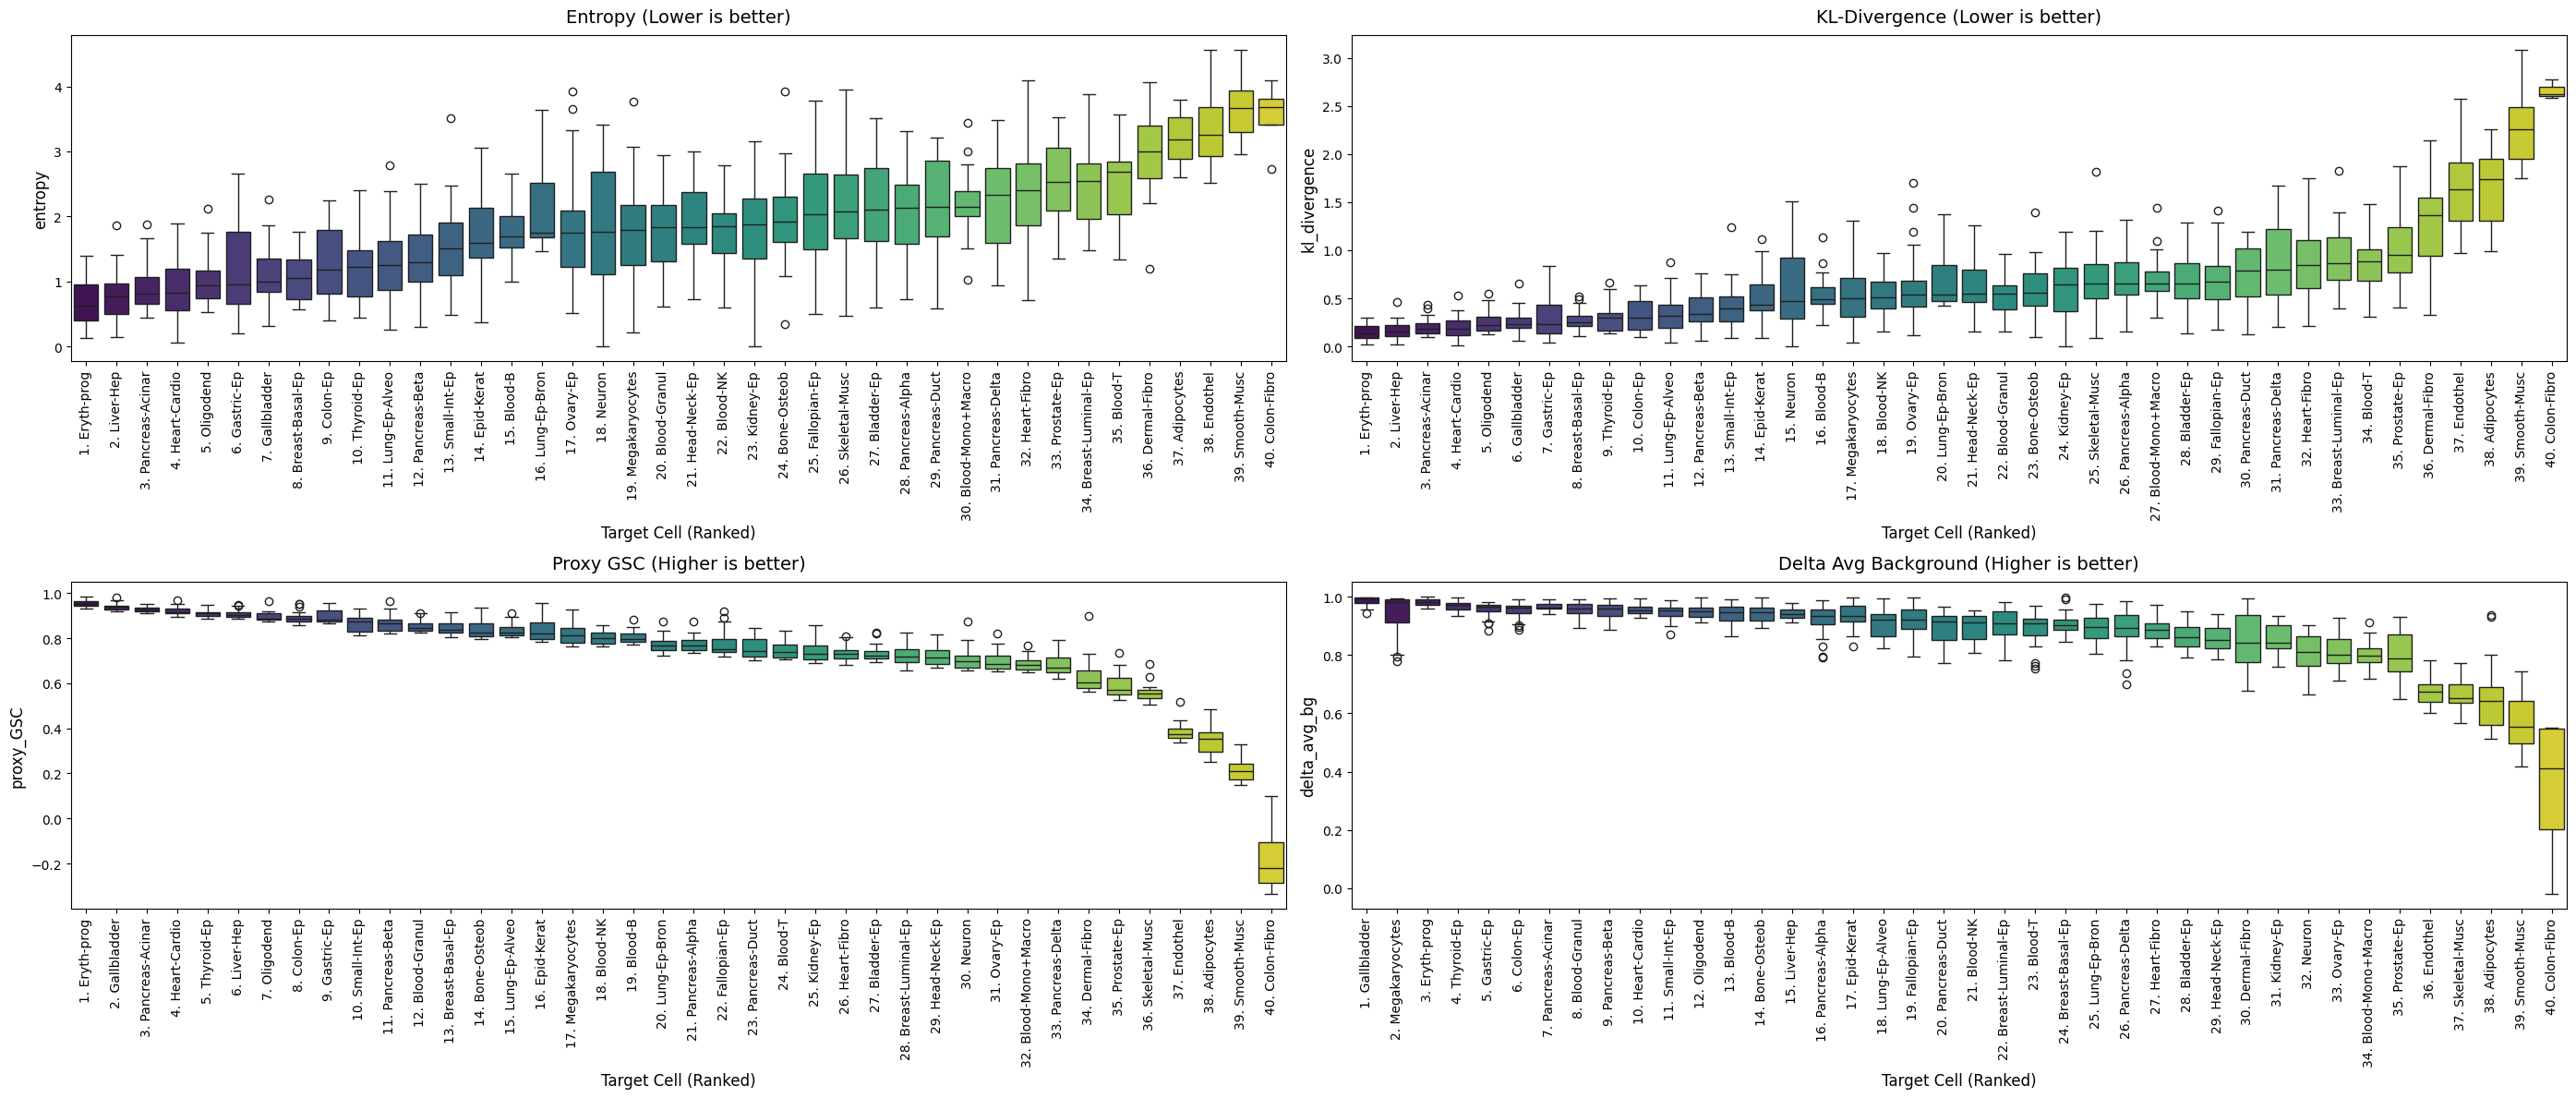

In [63]:
plot_methylation_metrics(subset)